### This is for testing attention results.

In [ ]:
#n script for reading train and validation data set and train the network
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Conv2D, Flatten, Input, MaxPooling2D, Activation, BatchNormalization, Concatenate, Dropout, Add, Dense,LeakyReLU
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2
import pandas as pd
from pathlib import Path
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow as tf
from tensorflow.keras.optimizers import SGD,RMSprop
from tensorflow.keras.applications import EfficientNetB0
from keras.applications.vgg16 import VGG16
from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input
from keras.layers import Input, Flatten, Dense, Lambda
from keras.models import Model
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from pathlib import Path
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from keras.models import model_from_json
#from plot import multi_plot
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc
import keras
import tensorflow as tf
from keras.callbacks import ModelCheckpoint
import pandas as pd
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.python.keras.layers import InputSpec, Layer
import os

from keras.callbacks import Callback
import matplotlib.pyplot as plt
import numpy as np
from scikitplot.metrics import plot_confusion_matrix, plot_roc, plot_precision_recall_curve, plot_precision_recall
import keras
from tensorflow.keras import utils
from keras.preprocessing.image import ImageDataGenerator, apply_affine_transform
from skimage import io
import random
from myplot import multi_plot


from keras.applications.vgg16 import VGG16
from keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten, Input, Conv2D, multiply, LocallyConnected2D, Lambda
from keras.models import Model

########### VGG16 model with attention layer

in_lay = Input((224,224,3))
base_pretrained_model = VGG16(include_top = False, weights = 'imagenet')
base_pretrained_model.trainable = False

#pt_depth = base_pretrained_model.get_output_shape_at(0)[-1]
pt_depth  =base_pretrained_model.layers[-1].output_shape[-1]

pt_features = base_pretrained_model(in_lay)
from keras.layers import BatchNormalization
bn_features = BatchNormalization()(pt_features)

# here we do an attention mechanism to turn pixels in the GAP on an off

attn_layer = Conv2D(64, kernel_size = (1,1), padding = 'same', activation = 'relu')(bn_features)
attn_layer = Conv2D(16, kernel_size = (1,1), padding = 'same', activation = 'relu')(attn_layer)
attn_layer = LocallyConnected2D(1, 
                                kernel_size = (1,1), 
                                padding = 'valid', 
                                activation = 'sigmoid',name='locally_connected')(attn_layer)
# fan it out to all of the channels
up_c2_w = np.ones((1, 1, 1, pt_depth))
up_c2 = Conv2D(pt_depth, kernel_size = (1,1), padding = 'same', 
               activation = 'linear', use_bias = False, weights = [up_c2_w])
up_c2.trainable = False
attn_layer = up_c2(attn_layer)

mask_features = multiply([attn_layer, bn_features])
gap_features = GlobalAveragePooling2D()(mask_features)
gap_mask = GlobalAveragePooling2D()(attn_layer)

# to account for missing values from the attention model
gap = Lambda(lambda x: x[0]/x[1], name = 'RescaleGAP')([gap_features, gap_mask])
gap_dr = Dropout(0.5)(gap)
dr_steps = Dropout(0.25)(Dense(1024, activation = 'elu')(gap_dr))
out_layer = Dense(3, activation = 'linear')(dr_steps) # linear is what 16bit did

Lung_score_model = Model(inputs = [in_lay], outputs = [out_layer])

Lung_score_model.summary()
METRICS = [
      keras.metrics.SparseCategoricalAccuracy(),
      ]


Lung_score_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy',  metrics = [METRICS])



Lung_score_model.load_weights('attention_result/2nd_part_attention_weights.09-0.49.hdf5')

attnModel = Model(
          inputs=[Lung_score_model.inputs],
          outputs=[Lung_score_model.get_layer('locally_connected').output])
    
print('done')


%matplotlib inline


import matplotlib.pyplot as plt



SAMPLES        = glob.glob('Attention_test/short_list/*.tif')
for img in SAMPLES:
    cur_img = cv2.imread(img)
    y = np.expand_dims(cur_img, axis=0) 


    plt.figure()
    plt.imshow(cur_img)
    plt.show()


    with tf.device('/CPU:0'):
        attn_img = attnModel(y)




    plt.show()
    plt.figure()

    new_attn_image = arr = np.array(attn_img, dtype=np.float)[0] 
    print(new_attn_image.shape)
    heatmap = cv2.resize(new_attn_image, (224, 224))
    stacked_img = np.stack((heatmap,), axis=-1) ## 
    im_color = cv2.applyColorMap((stacked_img*255).astype(np.uint8), cv2.COLORMAP_JET) ## add a color map

    #res = np.resize(new_attn_image,(224,224,1))
    #plt.imshow(result, cmap = 'viridis')
    super_imposed_img = cv2.addWeighted((im_color), 0.3, cur_img, 0.7,0)
    plt.imshow(super_imposed_img, cmap = 'jet')
    plt.colorbar()

    plt.figure()
    plt.imshow(im_color,cmap = 'jet')
    plt.colorbar()


SyntaxError: EOL while scanning string literal (441948724.py, line 122)

Model: "model_11"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_17 (InputLayer)          [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 vgg16 (Functional)             (None, None, None,   14714688    ['input_17[0][0]']               
                                512)                                                              
                                                                                                  
 batch_normalization_8 (BatchNo  (None, 7, 7, 512)   2048        ['vgg16[0][0]']                  
 rmalization)                                                                              

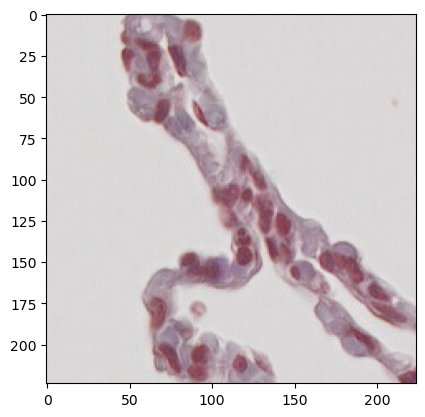

0
attention_test_fold2\Slide_10_2_Pig_2_control_MV_End_mv_ecmo_control_001.TIF_score_4___2_2.tif
(7, 7, 1)


C:\Users\salma\AppData\Local\Temp\ipykernel_22024\2296893012.py:161: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  new_attn_image = arr = np.array(attn_img, dtype=np.float)[0]


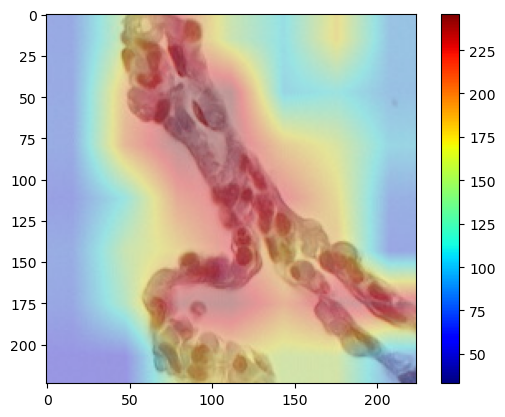

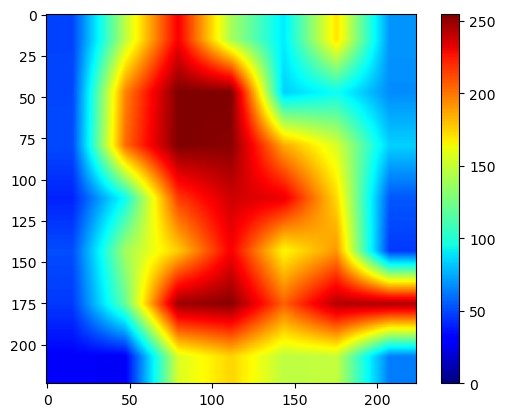

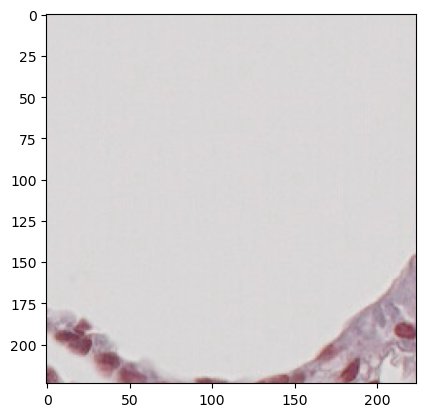

0
attention_test_fold2\Slide_10_2_Pig_2_control_MV_End_mv_ecmo_control_001.TIF_score_4___2_3.tif
(7, 7, 1)


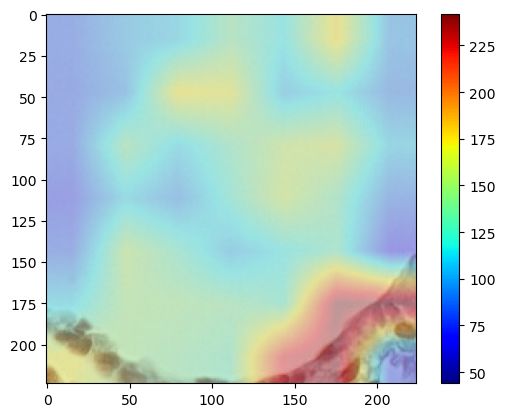

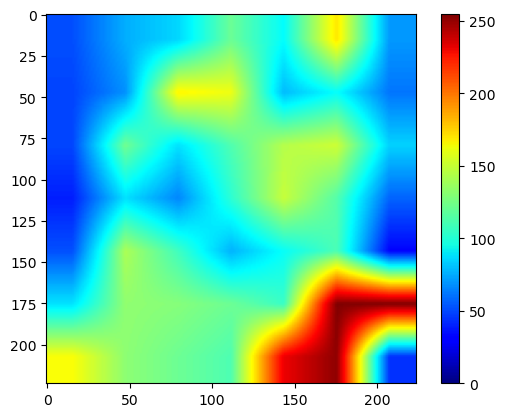

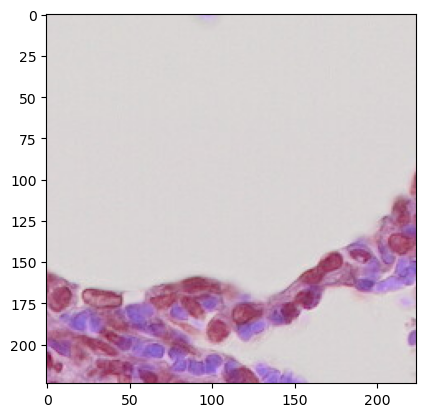

1
attention_test_fold2\Slide_5_190206_3_left_upper__mv_ecmo_positv001.TIF_score_21___1_1.tif
(7, 7, 1)


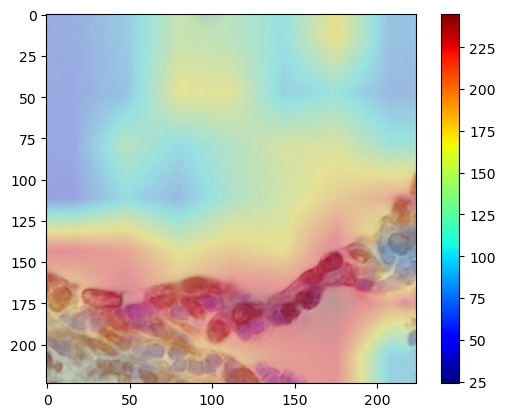

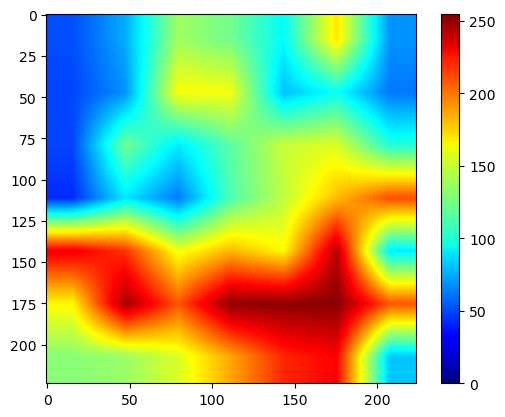

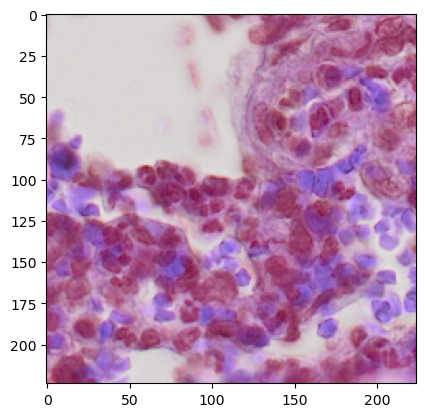

1
attention_test_fold2\Slide_5_190206_3_left_upper__mv_ecmo_positv001_2_score_21___0_5.tif
(7, 7, 1)


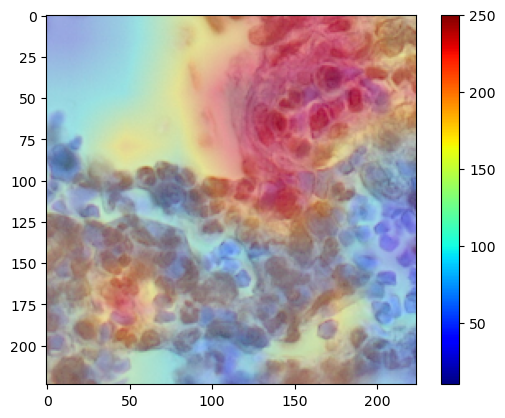

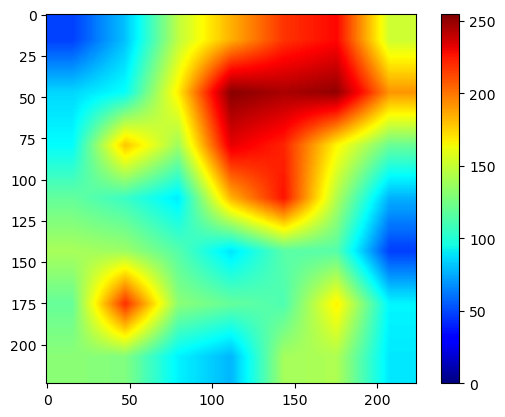

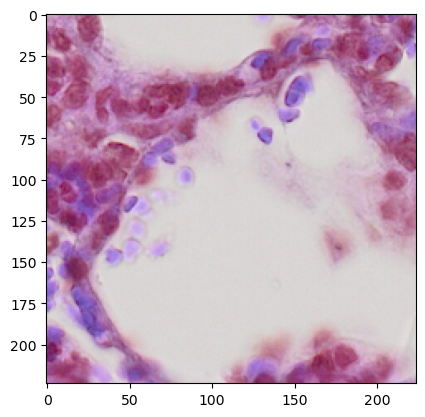

1
attention_test_fold2\Slide_5_190206_3_left_upper__mv_ecmo_positv001_2_score_21___0_6.tif
(7, 7, 1)


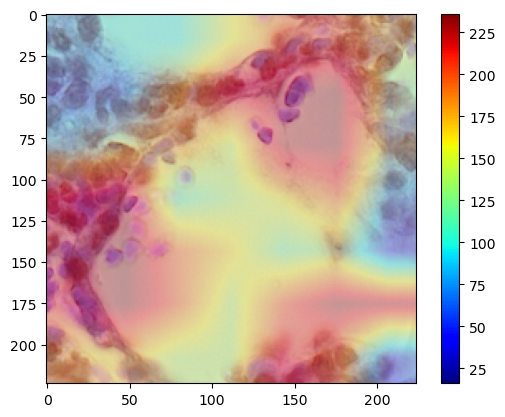

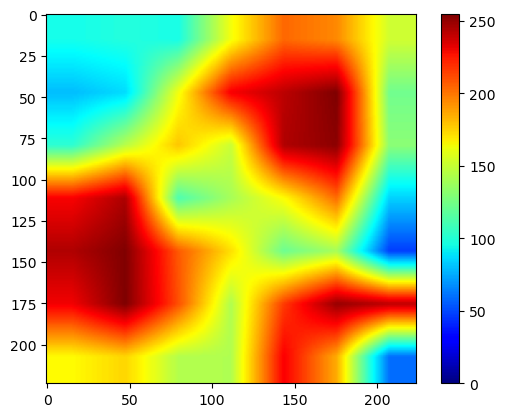

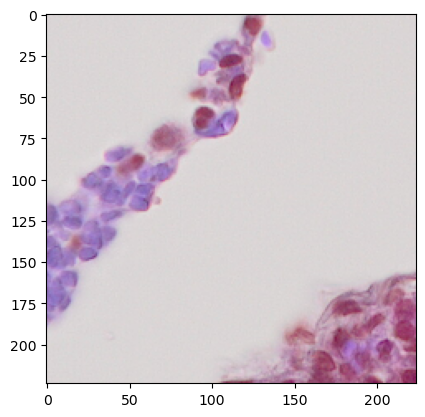

0
attention_test_fold2\Slide_5_190206_3_left_upper__mv_ecmo_positv001_3_score_21___0_0.tif
(7, 7, 1)


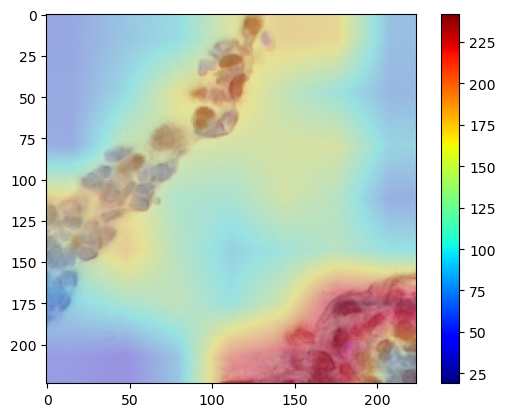

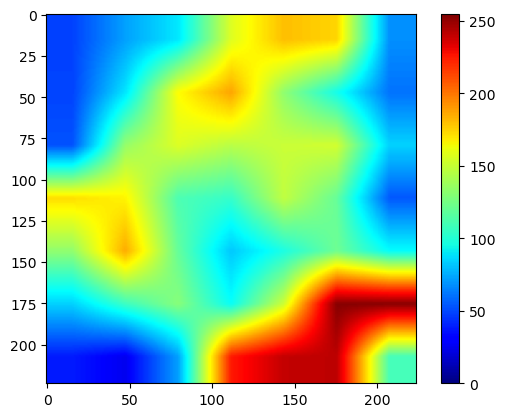

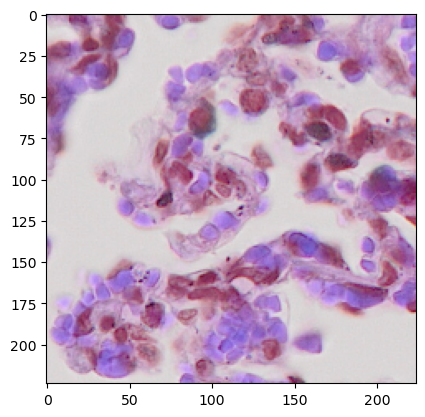

1
attention_test_fold2\Slide_6_190206_3_Right_lower_mv_ecmo_positv002_1_score_41___0_6.tif
(7, 7, 1)


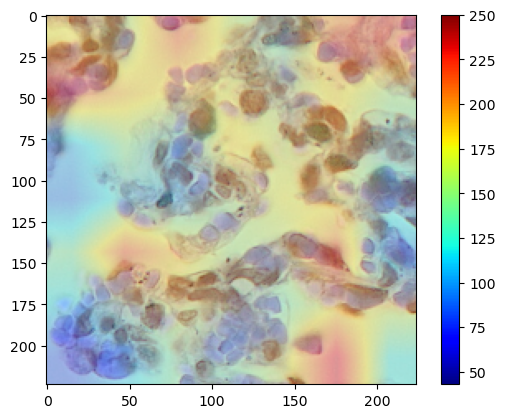

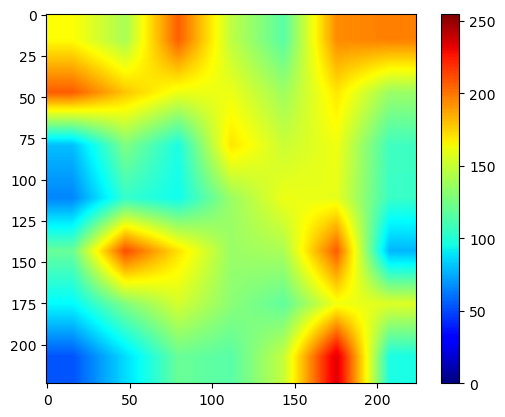

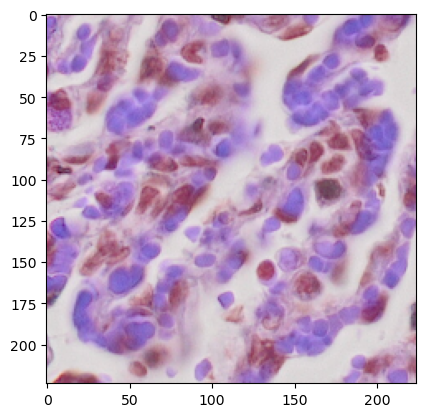

1
attention_test_fold2\Slide_6_190206_3_Right_lower_mv_ecmo_positv002_1_score_41___2_0.tif
(7, 7, 1)


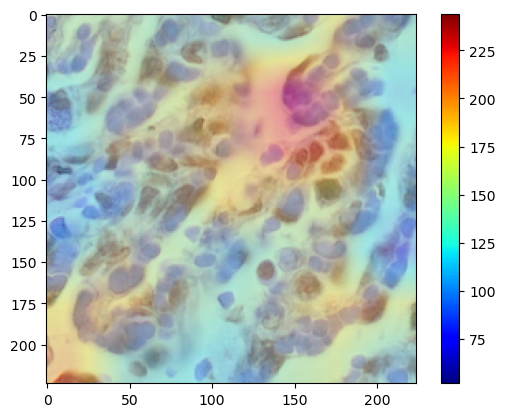

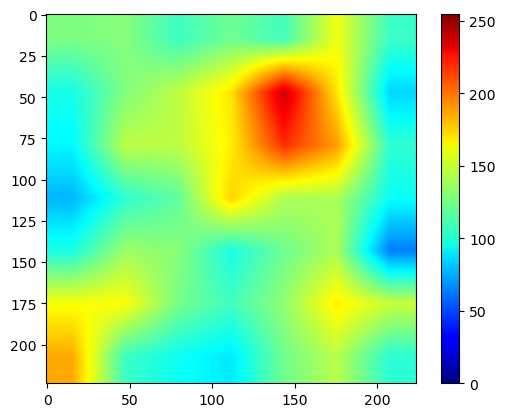

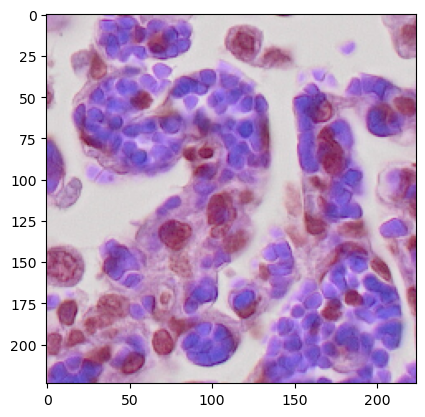

1
attention_test_fold2\Slide_6_190206_3_Right_lower_mv_ecmo_positv002_6_score_41___0_1.tif
(7, 7, 1)


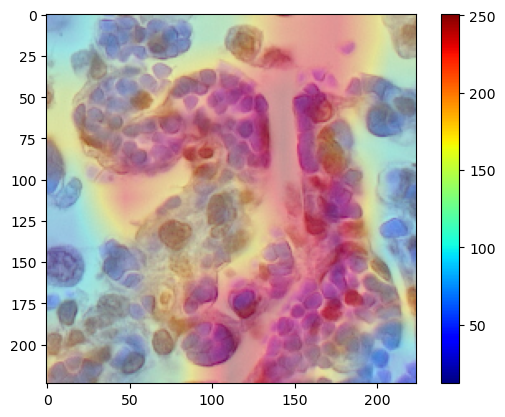

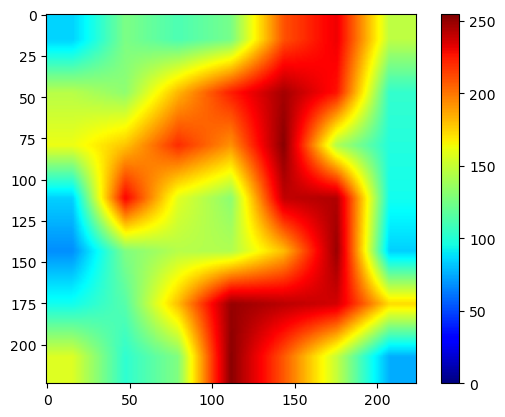

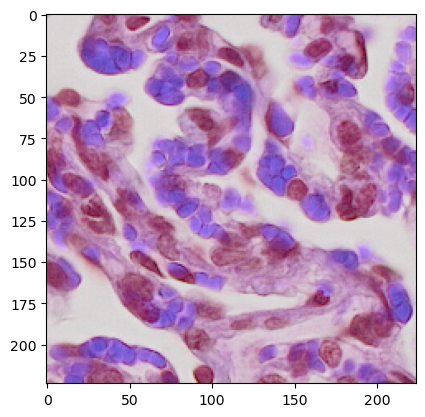

1
attention_test_fold2\Slide_6_190206_3_Right_lower_mv_ecmo_positv002_6_score_41___2_4.tif
(7, 7, 1)


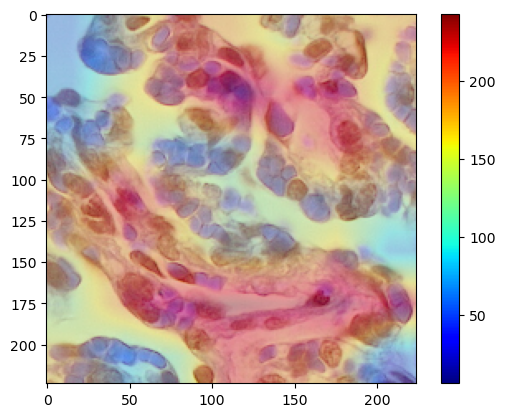

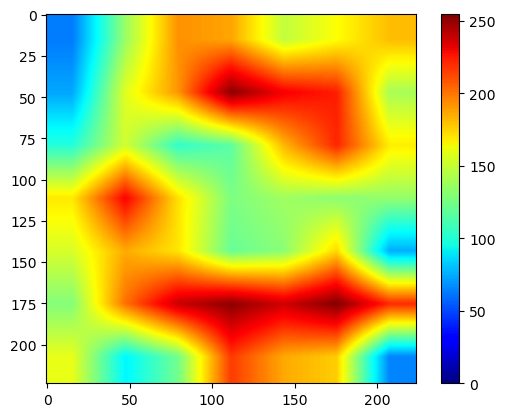

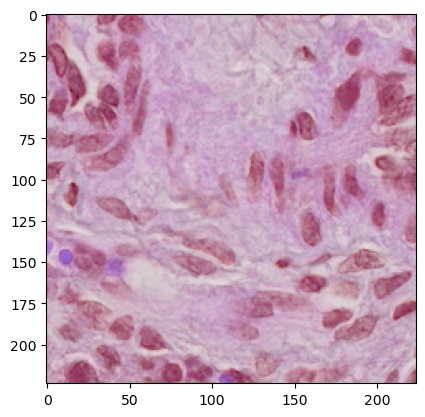

1
attention_test_fold2\Slide_6_190206_3_Right_lower_mv_ecmo_positv002_7_score_41___1_4.tif
(7, 7, 1)


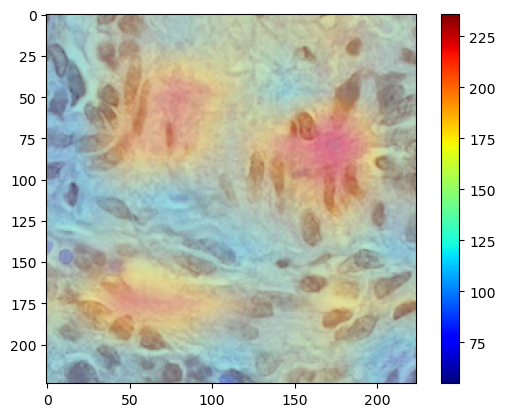

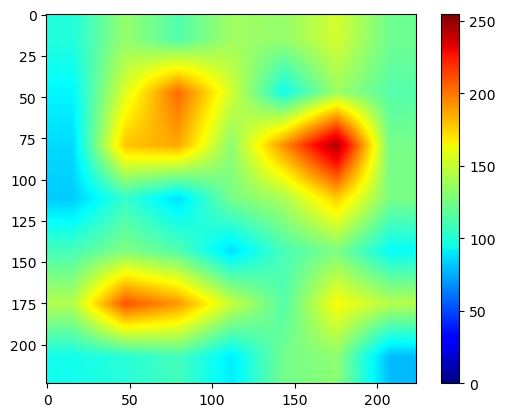

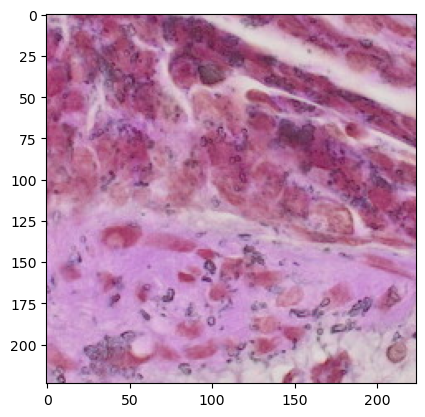

1
attention_test_fold2\Slide_7_190207_4_left_lower_mv_ecmo_positv003_10_score_36___1_1.tif
(7, 7, 1)


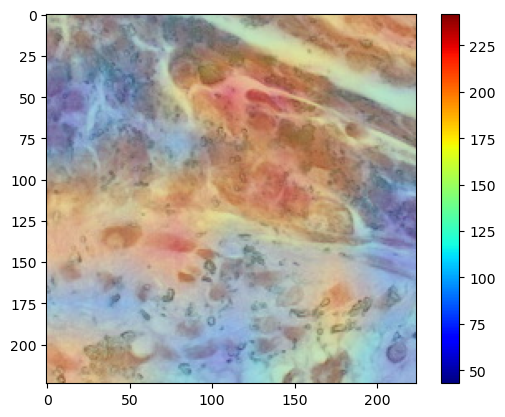

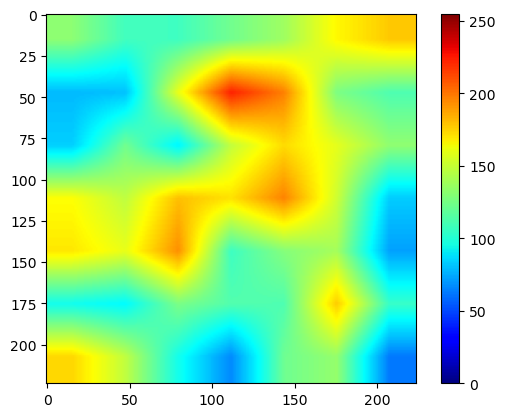

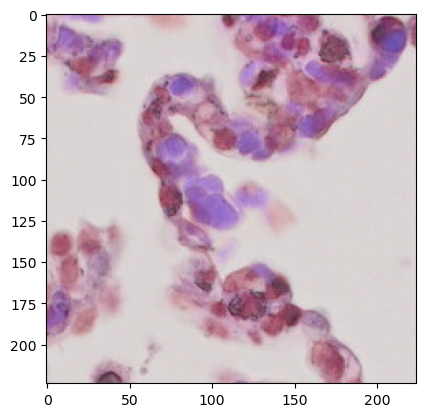

1
attention_test_fold2\Slide_7_190207_4_left_lower_mv_ecmo_positv003_4_score_36___2_3.tif
(7, 7, 1)


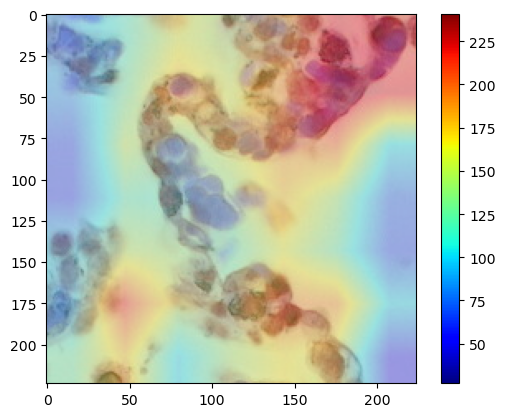

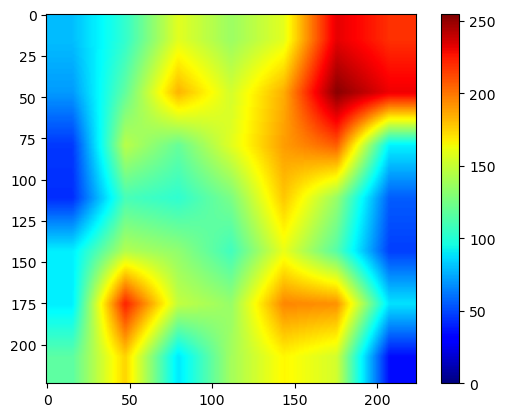

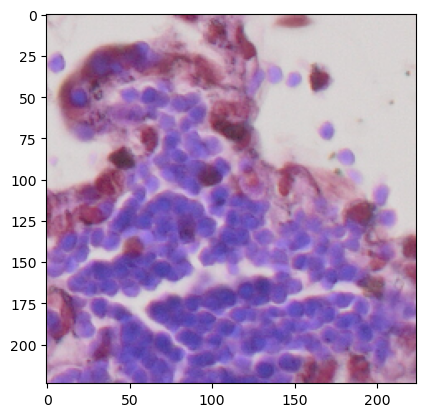

1
attention_test_fold2\Slide_8_190207_5_left_lower_mv_ecmo_positv005.TIF_score_24___1_0.tif
(7, 7, 1)


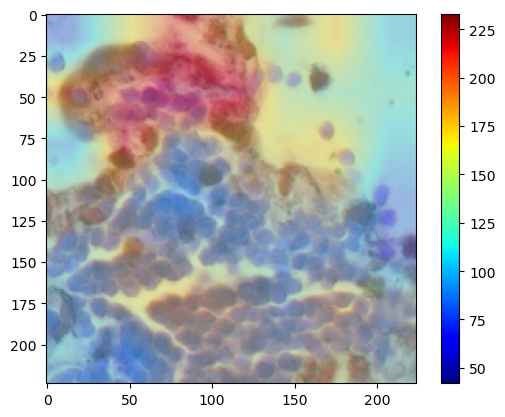

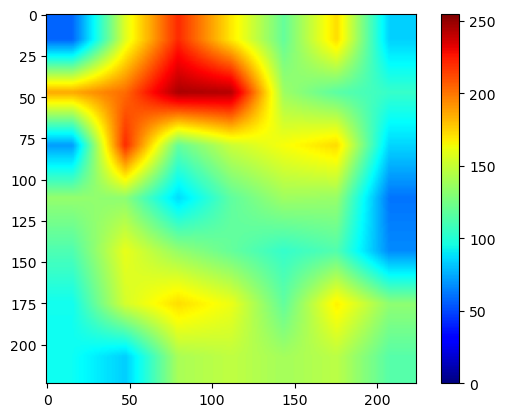

In [9]:
#n script for reading train and validation data set and train the network
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Conv2D, Flatten, Input, MaxPooling2D, Activation, BatchNormalization, Concatenate, Dropout, Add, Dense,LeakyReLU
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2
import pandas as pd
from pathlib import Path
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow as tf
from tensorflow.keras.optimizers import SGD,RMSprop
from tensorflow.keras.applications import EfficientNetB0
from keras.applications.vgg16 import VGG16
from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input
from keras.layers import Input, Flatten, Dense, Lambda
from keras.models import Model
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from pathlib import Path
from tensorflow.keras.utils import plot_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from keras.models import model_from_json
#from plot import multi_plot
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc
import keras
import tensorflow as tf
from keras.callbacks import ModelCheckpoint
import pandas as pd
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.python.keras.layers import InputSpec, Layer
import os

from keras.callbacks import Callback
import matplotlib.pyplot as plt
import numpy as np
from scikitplot.metrics import plot_confusion_matrix, plot_roc, plot_precision_recall_curve, plot_precision_recall
import keras
from tensorflow.keras import utils
from keras.preprocessing.image import ImageDataGenerator, apply_affine_transform
from skimage import io
import random
from myplot import multi_plot


from keras.applications.vgg16 import VGG16
from keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten, Input, Conv2D, multiply, LocallyConnected2D, Lambda
from keras.models import Model

########### VGG16 model with attention layer

in_lay = Input((224,224,3))
base_pretrained_model = VGG16(include_top = False, weights = 'imagenet')
base_pretrained_model.trainable = False

#pt_depth = base_pretrained_model.get_output_shape_at(0)[-1]
pt_depth  =base_pretrained_model.layers[-1].output_shape[-1]

pt_features = base_pretrained_model(in_lay)
from keras.layers import BatchNormalization
bn_features = BatchNormalization()(pt_features)

# here we do an attention mechanism to turn pixels in the GAP on an off

attn_layer = Conv2D(64, kernel_size = (1,1), padding = 'same', activation = 'relu')(bn_features)
attn_layer = Conv2D(16, kernel_size = (1,1), padding = 'same', activation = 'relu')(attn_layer)
attn_layer = LocallyConnected2D(1, 
                                kernel_size = (1,1), 
                                padding = 'valid', 
                                activation = 'sigmoid',name='locally_connected')(attn_layer)
# fan it out to all of the channels
up_c2_w = np.ones((1, 1, 1, pt_depth))
up_c2 = Conv2D(pt_depth, kernel_size = (1,1), padding = 'same', 
               activation = 'linear', use_bias = False, weights = [up_c2_w])
up_c2.trainable = False
attn_layer = up_c2(attn_layer)

mask_features = multiply([attn_layer, bn_features])
gap_features = GlobalAveragePooling2D()(mask_features)
gap_mask = GlobalAveragePooling2D()(attn_layer)

# to account for missing values from the attention model
gap = Lambda(lambda x: x[0]/x[1], name = 'RescaleGAP')([gap_features, gap_mask])
gap_dr = Dropout(0.5)(gap)
dr_steps = Dropout(0.25)(Dense(1024, activation = 'elu')(gap_dr))
out_layer = Dense(3, activation = 'linear')(dr_steps) # linear is what 16bit did

Lung_score_model = Model(inputs = [in_lay], outputs = [out_layer])

Lung_score_model.summary()
METRICS = [
      keras.metrics.SparseCategoricalAccuracy(),
      ]


Lung_score_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy',  metrics = [METRICS])



Lung_score_model.load_weights('attention_result/2nd_part_best_weights.07-1.10.hdf5')

attnModel = Model(
          inputs=[Lung_score_model.inputs],
          outputs=[Lung_score_model.get_layer('locally_connected').output])
    
print('done')


%matplotlib inline


import matplotlib.pyplot as plt



SAMPLES        = glob.glob('attention_test_fold2/*.tif')
for img in SAMPLES:
    cur_img = cv2.imread(img)
    y = np.expand_dims(cur_img, axis=0) 


    plt.figure()
    plt.imshow(cur_img)
    plt.show()


    with tf.device('/CPU:0'):
        attn_img = attnModel(y)
        predicted_y = Lung_score_model.predict(y)
        print(np.argmax(predicted_y))
        print(img)




    plt.show()
    plt.figure()

    new_attn_image = arr = np.array(attn_img, dtype=np.float)[0] 
    print(new_attn_image.shape)
    heatmap = cv2.resize(new_attn_image, (224, 224))
    stacked_img = np.stack((heatmap,), axis=-1) ## 
    im_color = cv2.applyColorMap((stacked_img*255).astype(np.uint8), cv2.COLORMAP_JET) ## add a color map

    #res = np.resize(new_attn_image,(224,224,1))
    #plt.imshow(result, cmap = 'viridis')
    super_imposed_img = cv2.addWeighted((im_color), 0.3, cur_img, 0.7,0)
    plt.imshow(super_imposed_img, cmap = 'jet')
    plt.colorbar()

    plt.figure()
    plt.imshow(im_color,cmap = 'jet')
    plt.colorbar()
